In [59]:
import pandas as pd

In [60]:
df = pd.read_csv("../Snowflake Notebooks Package/data/data_join.csv")
df.head(5)

,LATITUDE,LONGITUDE,DATE,TOTALAL_KALINITY,ELECTRICAL_CONDUCTANCE,DISSOLVED_REACTIVE_PHOSPHORUS,PET,NIR,GREEN,SWIR16,SWIR22,NDMI,MNDWI
0,-28.760833,17.730278,02-01-2011,128.912,555.0,10.0,174.2,11190.0,11426.0,7687.5,7645.0,0.185538,0.195595
1,-26.861111,28.884722,03-01-2011,74.720,162.9,163.0,124.1,17658.5,9550.0,13746.5,10574.0,0.124566,-0.180134
2,-26.450000,28.085833,03-01-2011,89.254,573.0,80.0,127.5,15210.0,10720.0,17974.0,14201.0,-0.083293,-0.252805
3,-27.671111,27.236944,03-01-2011,82.000,203.6,101.0,129.7,14887.0,10943.0,13522.0,11403.0,0.048048,-0.105416
4,-27.356667,27.286389,03-01-2011,56.100,145.1,151.0,129.2,16828.5,9502.5,12665.5,9643.0,0.141147,-0.142683


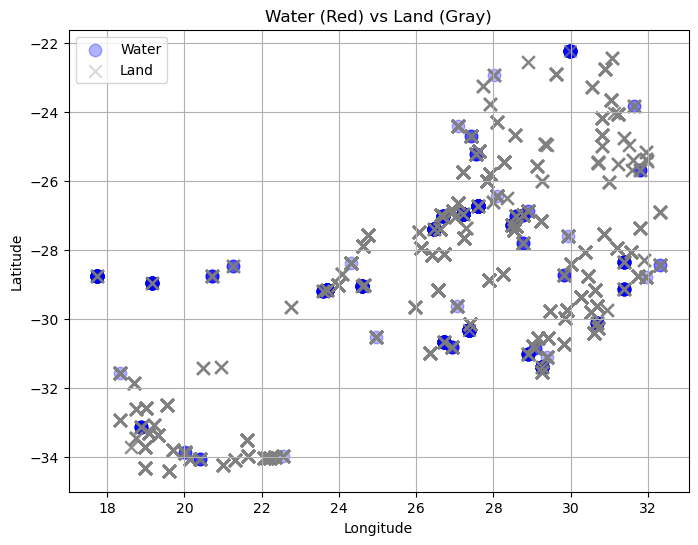

In [61]:
import matplotlib.pyplot as plt

df["water"] = df["MNDWI"] > 0

plt.figure(figsize=(8,6))

water = df[df["water"] == True]
plt.scatter(
    water["LONGITUDE"],
    water["LATITUDE"],
    c="blue",
    marker='o',
    s=80,
    alpha=0.3,
    label="Water"
)

land = df[df["water"] == False]
plt.scatter(
    land["LONGITUDE"],
    land["LATITUDE"],
    c="gray",
    marker='x',
    s=80,
    alpha=0.3,
    label="Land"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Water (Red) vs Land (Gray)")
plt.legend()
plt.grid()
plt.show()

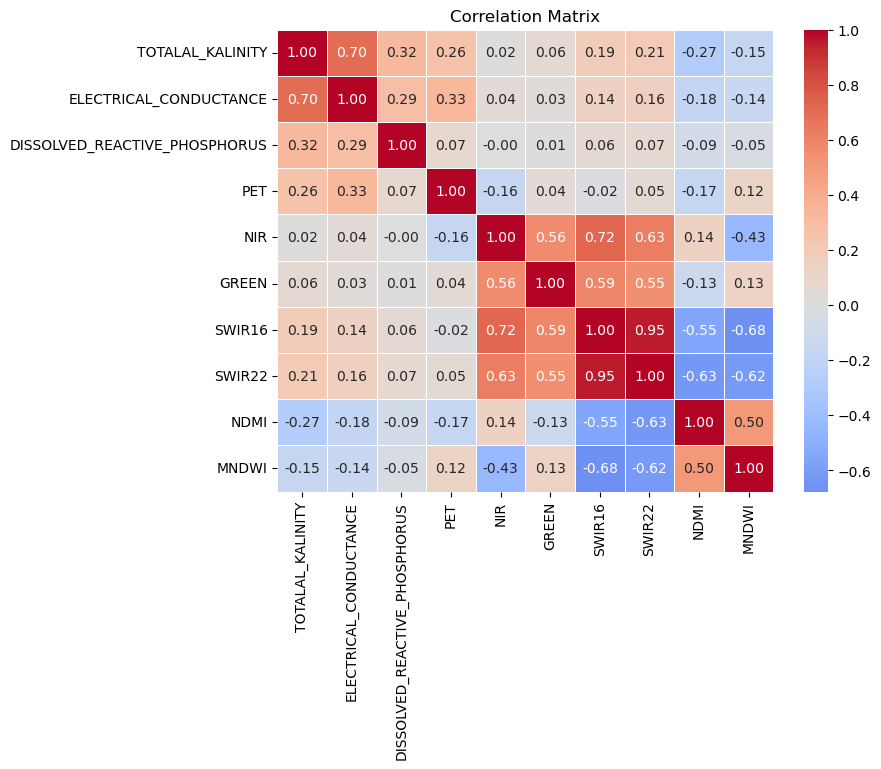

In [62]:
import seaborn as sns

corr_df = df[["TOTALAL_KALINITY", "ELECTRICAL_CONDUCTANCE", "DISSOLVED_REACTIVE_PHOSPHORUS", "PET", "NIR", "GREEN", "SWIR16", "SWIR22", "NDMI", "MNDWI"]].dropna()

corr_matrix = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.7)
plt.title("Correlation Matrix")
plt.show()  

In [64]:
df["water_moisture_index"] = df["NDMI"] * df["MNDWI"]
df["evaporation_stress"] = df["PET"] / (df["NDMI"] + 1e-6)
df["SWIR_ratio"] = df["SWIR16"] / (df["SWIR22"] + 1e-6)
df["is_water"] = df["MNDWI"] > 0

df["DATE"] = pd.to_datetime(df["DATE"], format='%d-%m-%Y')
df["month"] = df["DATE"].dt.month
df["year"] = df["DATE"].dt.year
df["dayofyear"] = df["DATE"].dt.dayofyear

In [66]:
df.columns

Index(['LATITUDE', 'LONGITUDE', 'DATE', 'TOTALAL_KALINITY',
       'ELECTRICAL_CONDUCTANCE', 'DISSOLVED_REACTIVE_PHOSPHORUS', 'PET', 'NIR',
       'GREEN', 'SWIR16', 'SWIR22', 'NDMI', 'MNDWI', 'water',
       'water_moisture_index', 'evaporation_stress', 'SWIR_ratio', 'is_water',
       'month', 'year', 'dayofyear'],
      dtype='str')

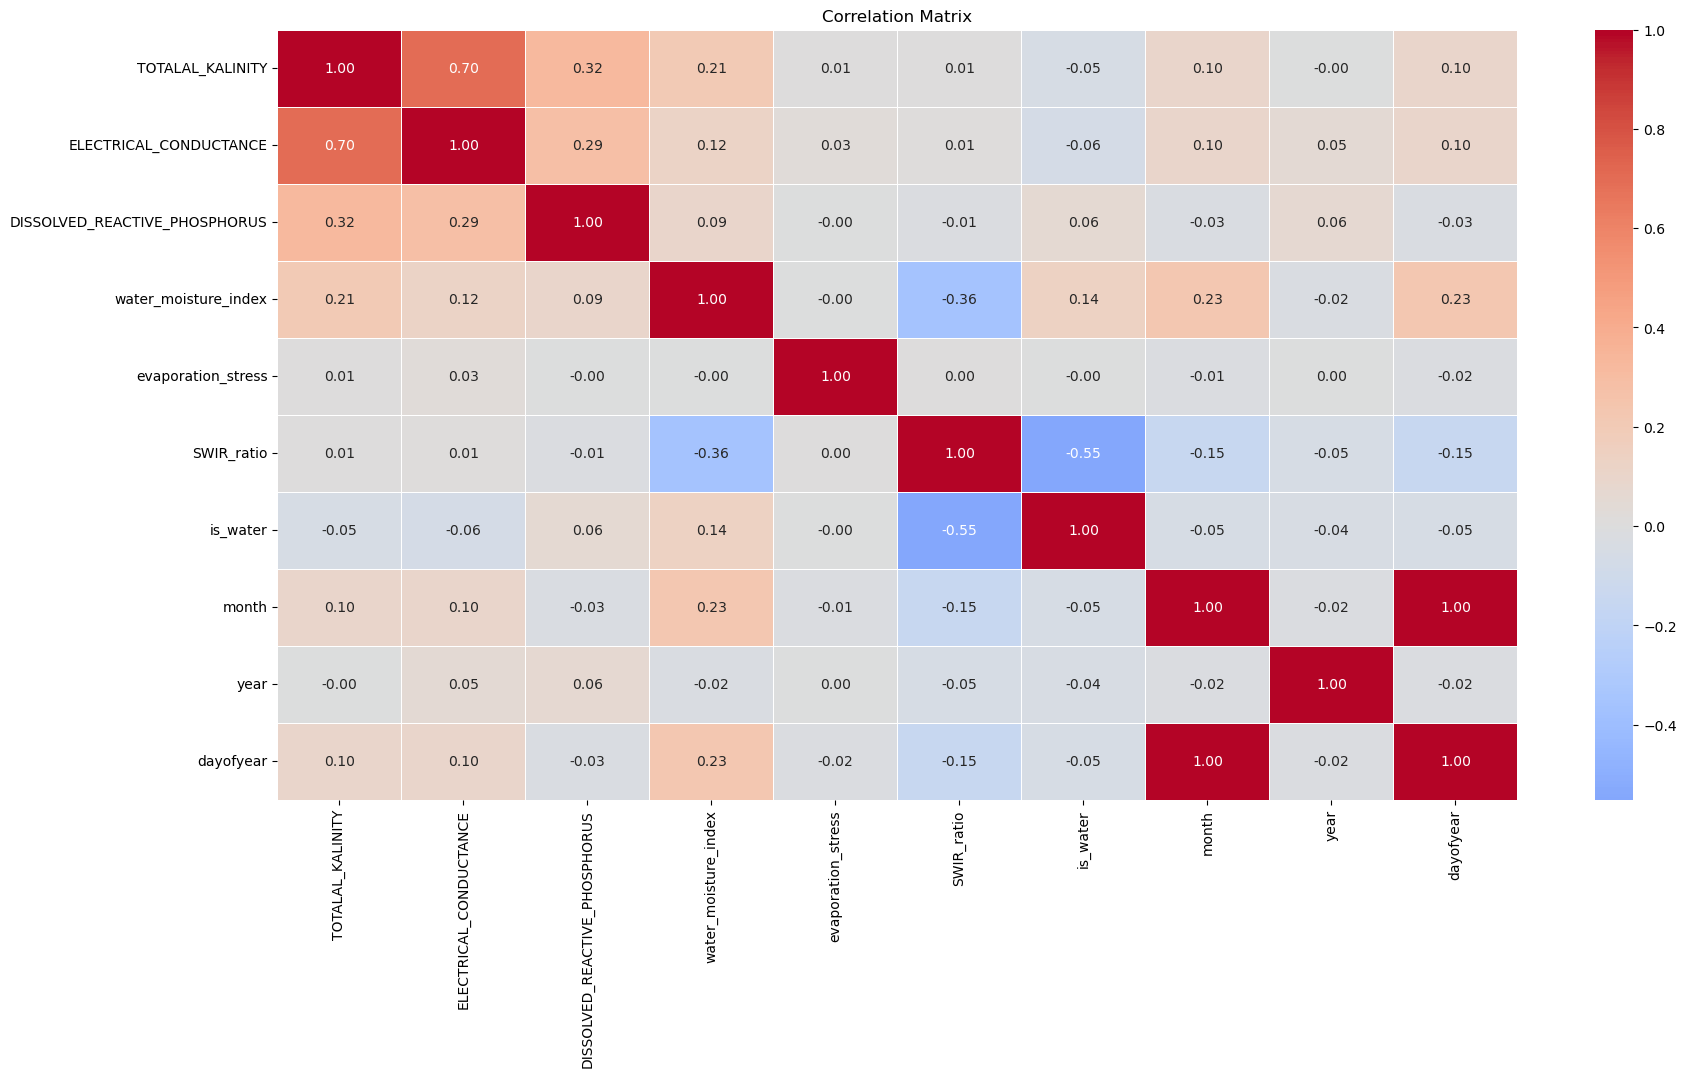

In [67]:

corr_df = df[[ 'TOTALAL_KALINITY','ELECTRICAL_CONDUCTANCE', 'DISSOLVED_REACTIVE_PHOSPHORUS','water_moisture_index', 'evaporation_stress', 'SWIR_ratio', 'is_water',
       'month', 'year', 'dayofyear']].dropna()

corr_matrix_2 = corr_df.corr()

plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix_2, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.7)
plt.title("Correlation Matrix")
plt.show()  

In [ ]:
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

targets = [
    'TOTALAL_KALINITY',
    'ELECTRICAL_CONDUCTANCE',
    'DISSOLVED_REACTIVE_PHOSPHORUS'
]

df = df.sort_values("DATE").reset_index(drop=True)

X = df.drop(columns=targets + ['DATE'])
y_dict = {t: df[t].values for t in targets}

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

for target in targets:
    y = y_dict[target]
    rmse_list = []
    
    for train_idx, val_idx in tscv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model = LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        )
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
            LGBMRegressor.__module__.split('.')[0] and __import__('lightgbm').early_stopping(50),
            __import__('lightgbm').log_evaluation(0)
            ]
        )
        
        y_pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)
    
    print(f"{target} Avg RMSE: {np.mean(rmse_list):.4f}")

TypeError: LGBMRegressor.fit() got an unexpected keyword argument 'early_stopping_rounds'